In [ ]:
import xarray as xr
from xarray.coding.times import CFTimedeltaCoder
import numpy as np
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import cmocean
import cartopy.crs as ccrs
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter, RRuleLocator, rrulewrapper
from dateutil.rrule import rrule, DAILY

%cd functions
from model_obs_comparison import *
from calc_aerosol import *

### Observations

In [9]:
obs_dir = 'obs/formatted/'

# RRAP February 2022 RV Magnetic observations (~10 m)
rrap_22_gps = pd.read_csv(obs_dir + 'RRAP_Feb_2022_gps.csv', parse_dates=['time'])                 # RV Magnetic GPS (lat.interp, lon.interp)
rrap_22_N10 = pd.read_csv(obs_dir + 'RRAP_Feb_2022_N10.csv', parse_dates=['time'])                 # N10 (conc)
rrap_22_ccn = pd.read_csv(obs_dir + 'RRAP_Feb_2022_CCN.csv', parse_dates=['time'])                 # CCN 0.2% SS (conc)

# RRAP March 2023 Heron Island Research Station observations (~5 m)
rrap_23_N10 = pd.read_csv(obs_dir + 'RRAP_Mar_2023_N10.csv', parse_dates=['time'])                 # N10 (conc)
rrap_23_ccn = pd.read_csv(obs_dir + 'RRAP_Mar_2023_CCN.csv', parse_dates=['time'])                 # CCN 0.2% SS (conc)
rrap_23_AMS = pd.read_csv(obs_dir + 'RRAP_Mar_2023_AMS.csv', parse_dates=['time'])                 # Aerosol organics (HROrg) & sulfate (HRSO4) mass
rrap_23_BC = pd.read_csv(obs_dir + 'RRAP_Mar_2023_BC.csv', parse_dates=['time'])                   # Black carbon (BCx)
rrap_23_SD = pd.read_csv(obs_dir + 'RRAP_Mar_2023_SizeDist.csv', parse_dates=['time'])             # Aerosol size distribution

# AERONET Lucinda (8 m)
aeronet_22 = pd.read_csv(obs_dir + 'aeronet_Feb_2022.csv', parse_dates=['time'])                   # AOD
aeronet_23 = pd.read_csv(obs_dir + 'aeronet_Mar_2023.csv', parse_dates=['time'])

# AIMS Weather Stations
ws_davies_22 = pd.read_csv(obs_dir + 'AIMS_WS_Davies_2022.csv', parse_dates=['time'])              # Davies Reef air temp, pressure, wind speed & direction (10 m)
ws_davies_23 = pd.read_csv(obs_dir + 'AIMS_WS_Davies_2023.csv', parse_dates=['time'])
ws_heron_22 = pd.read_csv(obs_dir + 'AIMS_WS_Heron_2022.csv', parse_dates=['time'])                # Heron Island air temp, pressure, wind speed & direction (2022 only) (6 m)

# EcoRRAP seawater loggers
ER_Davies_22 = pd.read_csv(obs_dir + 'EcoRRAP_seawater_Davies_2022.csv', parse_dates=['time'])     # Davies Reef lagoon flat (2 m temp), front shallow (5 m temp) & front deep (13 m temp, salinity, PAR)
ER_Davies_23 = pd.read_csv(obs_dir + 'EcoRRAP_seawater_Davies_2023.csv', parse_dates=['time'])
ER_Heron_22 = pd.read_csv(obs_dir + 'EcoRRAP_seawater_Heron_2022.csv', parse_dates=['time'])       # Heron Island lagoon shallow (5 m temp), front shallow (5 m temp) & front deep (14.5 m temp, salinity, PAR)
ER_Heron_23 = pd.read_csv(obs_dir + 'EcoRRAP_seawater_Heron_2023.csv', parse_dates=['time'])

### Model

In [8]:
ctl_suite = 'ds142'
rev_suite = 'dn070'
model_dir = 'UM_NS/output/RRAP/ACCESS-EMS-GBR/'
rgn = 'NE_Aus'
res = '4km'
fcst = 48
lev_height = 20 # max height to read (m)
aod_level = 2   # AOD wavelength (550 nm)

# Read atmospheric model output
access_ctl_22 = xr.open_mfdataset(model_dir+'u-'+ctl_suite+'/um2nc/'+ctl_suite+'-'+rgn+'-'+res+'-'+str(fcst)+'hrFcst-2022*', concat_dim='time', combine='nested', data_vars='different', decode_timedelta=CFTimedeltaCoder(decode_via_units=True), chunks={})
access_ctl_23 = xr.open_mfdataset(model_dir+'u-'+ctl_suite+'/um2nc/'+ctl_suite+'-'+rgn+'-'+res+'-'+str(fcst)+'hrFcst-2023*', concat_dim='time', combine='nested', data_vars='different', decode_timedelta=CFTimedeltaCoder(decode_via_units=True), chunks={})

access_rev_22 = xr.open_mfdataset(model_dir+'u-'+rev_suite+'/um2nc/'+rev_suite+'-'+rgn+'-'+res+'-'+str(fcst)+'hrFcst-2022*', concat_dim='time', combine='nested', data_vars='different', decode_timedelta=CFTimedeltaCoder(decode_via_units=True), chunks={})
access_rev_23 = xr.open_mfdataset(model_dir+'u-'+rev_suite+'/um2nc/'+rev_suite+'-'+rgn+'-'+res+'-'+str(fcst)+'hrFcst-2023*', concat_dim='time', combine='nested', data_vars='different', decode_timedelta=CFTimedeltaCoder(decode_via_units=True), chunks={})

# Format atmospheric datasets (simpler indexing and interpolation)
access_ctl_22['WindSpeed'] = access_ctl_22['WindSpeed'].swap_dims({'model_level_number':'level_height_0'})
access_ctl_22['WindDir'] = access_ctl_22['WindDir'].swap_dims({'model_level_number':'level_height_0'})
access_ctl_22 = access_ctl_22.swap_dims({'model_level_number':'level_height'})

access_ctl_23['WindSpeed'] = access_ctl_23['WindSpeed'].swap_dims({'model_level_number':'level_height_0'})
access_ctl_23['WindDir'] = access_ctl_23['WindDir'].swap_dims({'model_level_number':'level_height_0'})
access_ctl_23 = access_ctl_23.swap_dims({'model_level_number':'level_height'})

access_rev_22['WindSpeed'] = access_rev_22['WindSpeed'].swap_dims({'model_level_number':'level_height_0'})
access_rev_22['WindDir'] = access_rev_22['WindDir'].swap_dims({'model_level_number':'level_height_0'})
access_rev_22 = access_rev_22.swap_dims({'model_level_number':'level_height'})

access_rev_23['WindSpeed'] = access_rev_23['WindSpeed'].swap_dims({'model_level_number':'level_height_0'})
access_rev_23['WindDir'] = access_rev_23['WindDir'].swap_dims({'model_level_number':'level_height_0'})
access_rev_23 = access_rev_23.swap_dims({'model_level_number':'level_height'})

# Subset by level
access_ctl_22 = access_ctl_22.sel(level_height=slice(0,lev_height), level_height_0=slice(0,lev_height), pseudo_level=aod_level)
access_ctl_23 = access_ctl_23.sel(level_height=slice(0,lev_height), level_height_0=slice(0,lev_height), pseudo_level=aod_level)
access_rev_22 = access_rev_22.sel(level_height=slice(0,lev_height), level_height_0=slice(0,lev_height), pseudo_level=aod_level)
access_rev_23 = access_rev_23.sel(level_height=slice(0,lev_height), level_height_0=slice(0,lev_height), pseudo_level=aod_level)

# Read in ocean model output
ems_22 = xr.open_mfdataset(model_dir+'u-'+rev_suite+'/gbr4_bgc/gbr4_bgc_all_hr_2022*', concat_dim='record', combine='nested', data_vars='different')
ems_23 = xr.open_mfdataset(model_dir+'u-'+rev_suite+'/gbr4_bgc/gbr4_bgc_all_hr_2023*', concat_dim='record', combine='nested', data_vars='different')

# Format ocean datasets (simpler indexing and interpolation)
ems_22 = ems_22.swap_dims({'k_centre':'z_centre', 'record':'t'})
ems_22 = ems_22.assign_coords(t = pd.to_datetime(ems_22['t']).round('h'))
ems_22 = ems_22.rename({'t':'time'})

ems_23 = ems_23.swap_dims({'k_centre':'z_centre', 'record':'t'})
ems_23 = ems_23.assign_coords(t = pd.to_datetime(ems_23['t']).round('h'))
ems_23 = ems_23.rename({'t':'time'})

### Get model output for obs locations

Align timestamps (for ship track), extract the nearest model gridcell to the observation coordinates, then interpolate the model to the observation height/depth.

In [4]:
# RV Magnetic ship track (RRAP Feb 2022)
access_ctl_22_ship, rrap_22_gps = align_times(access_ctl_22, rrap_22_gps)
access_rev_22_ship, dummy = align_times(access_rev_22, rrap_22_gps)

access_ctl_22_ship = get_model4shiptrack(access_ctl_22_ship, rrap_22_gps)
access_rev_22_ship = get_model4shiptrack(access_rev_22_ship, rrap_22_gps)

access_ctl_22_ship = access_ctl_22_ship.interp(level_height=10, level_height_0=10)
access_rev_22_ship = access_rev_22_ship.interp(level_height=10, level_height_0=10)

# Heron Island Research Station (RRAP March 2023)
access_ctl_23_heron = get_model4coord(access_ctl_23, -23.4426, 151.9130) 
access_rev_23_heron = get_model4coord(access_rev_23, -23.4426, 151.9130) 

access_ctl_23_heron = access_ctl_23_heron.interp(level_height=5, level_height_0=5)
access_rev_23_heron = access_rev_23_heron.interp(level_height=5, level_height_0=5)

# AERONET Lucinda
access_ctl_22_aeronet = get_model4coord(access_ctl_22, -18.5198, 146.3861)
access_rev_22_aeronet = get_model4coord(access_rev_22, -18.5198, 146.3861)

access_ctl_23_aeronet = get_model4coord(access_ctl_23, -18.5198, 146.3861)
access_rev_23_aeronet = get_model4coord(access_rev_23, -18.5198, 146.3861)

access_ctl_22_aeronet = access_ctl_22_aeronet.interp(level_height=8)
access_rev_22_aeronet = access_rev_22_aeronet.interp(level_height=8)

access_ctl_23_aeronet = access_ctl_23_aeronet.interp(level_height=8)
access_rev_23_aeronet = access_rev_23_aeronet.interp(level_height=8)

# AIMS Davies Reef Weather Station
access_daviesWS_22 = get_model4coord(access_rev_22,  -18.8316, 147.6345)
access_daviesWS_23 = get_model4coord(access_rev_23, -18.8316, 147.6345) 

access_daviesWS_22 = access_daviesWS_22.interp(level_height=10, level_height_0=10) 
access_daviesWS_23 = access_daviesWS_23.interp(level_height=10, level_height_0=10) 

# AIMS Heron Island Weather Station (2022 only)
access_heronWS_22 = get_model4coord(access_rev_22, -23.4482, 151.9839)
access_heronWS_22 = access_heronWS_22.interp(level_height=6, level_height_0=6)

# EcoRRAP Davies Reef 'lagoon flat', 'front shallow' and 'front deep' sites
ems_davies_22_LF = get_model4coord(ems_22, ER_Davies_22.LF_lat.iloc[0], ER_Davies_22.LF_lon.iloc[0])
ems_davies_22_FS = get_model4coord(ems_22, ER_Davies_22.FS_lat.iloc[0], ER_Davies_22.FS_lon.iloc[0])
ems_davies_22_FD = get_model4coord(ems_22, ER_Davies_22.FD_CTD_lat.iloc[0], ER_Davies_22.FD_CTD_lon.iloc[0])

ems_davies_23_LF = get_model4coord(ems_23, ER_Davies_23.LF_lat.iloc[0], ER_Davies_23.LF_lon.iloc[0])
ems_davies_23_FS = get_model4coord(ems_23, ER_Davies_23.FS_lat.iloc[0], ER_Davies_23.FS_lon.iloc[0])
ems_davies_23_FD = get_model4coord(ems_23, ER_Davies_23.FD_CTD_lat.iloc[0], ER_Davies_23.FD_CTD_lon.iloc[0])

ems_davies_22_LF = ems_davies_22_LF.interp(z_centre=-0.5)
ems_davies_22_FS = ems_davies_22_FS.interp(z_centre=-3.8)
ems_davies_22_FD = ems_davies_22_FD.interp(z_centre=-13)

ems_davies_23_LF = ems_davies_23_LF.interp(z_centre=-0.5)
ems_davies_23_FS = ems_davies_23_FS.interp(z_centre=-3.8)
ems_davies_23_FD = ems_davies_23_FD.interp(z_centre=-13)

# EcoRRAP Heron Island 'lagoon shallow', 'front shallow' and 'front deep' sites
ems_heron_22_LS = get_model4coord(ems_22, ER_Heron_22.LS_lat.iloc[0], ER_Heron_22.LS_lon.iloc[0])
ems_heron_22_FS = get_model4coord(ems_22, ER_Heron_22.FS_lat.iloc[0], ER_Heron_22.FS_lon.iloc[0])
ems_heron_22_FD = get_model4coord(ems_22, ER_Heron_22.FD_PAR_lat.iloc[0], ER_Heron_22.FD_PAR_lon.iloc[0])

ems_heron_23_FS = get_model4coord(ems_23, ER_Heron_23.FS_lat.iloc[0], ER_Heron_23.FS_lon.iloc[0])
ems_heron_23_FD = get_model4coord(ems_23, ER_Heron_23.FD_CTD_lat.iloc[0], ER_Heron_23.FD_CTD_lon.iloc[0])

ems_heron_22_LS = ems_heron_22_LS.interp(z_centre=-5)
ems_heron_22_FS = ems_heron_22_FS.interp(z_centre=-5)
ems_heron_22_FD = ems_heron_22_FD.interp(z_centre=-14.5)

ems_heron_23_FS = ems_heron_23_FS.interp(z_centre=-5)
ems_heron_23_FD = ems_heron_23_FD.interp(z_centre=-14.5)
# No data for 'Front shallow' site in 2023

Timestamps aligned.
Timestamps aligned.


In [10]:
# Heron Island Research Station (RRAP March 2023)
access_ctl_23_heron = get_model4coord(access_ctl_23, -23.4426, 151.9130) 
access_rev_23_heron = get_model4coord(access_rev_23, -23.4426, 151.9130) 

access_ctl_23_heron = access_ctl_23_heron.interp(level_height=5, level_height_0=5)
access_rev_23_heron = access_rev_23_heron.interp(level_height=5, level_height_0=5)

### Plot settings

In [5]:
fontsize = 20
plt.rcParams.update({'font.size':fontsize, 'mathtext.default':'regular'})
date_form = DateFormatter("%d-%m-%Y")
obs_line = {'linestyle':'', 'color':'k', 'marker':'.', 'markersize':10, 'linewidth':1}                           # Observations
model_line1 = {'linestyle':'', 'color':'slategrey', 'marker':'.', 'markersize':10, 'linewidth':1, 'alpha':0.5}   # Modelled (control aerosol)
model_line2 = {'linestyle':'', 'color':'C0', 'marker':'.', 'markersize':10, 'linewidth':1, 'alpha':0.7}          # Modelled (revised aerosol)
plt_labels = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P']
fig_dir = 'plots/'

### Map of observation locations

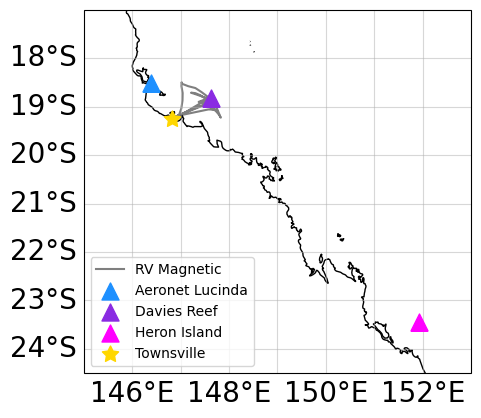

In [7]:
fig = plt.figure(figsize=(5,7))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
ax.set_extent((145,153,-24.5,-17))
gls = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, alpha=0.5)
gls.top_labels=False
gls.right_labels=False 

plt.plot(rrap_22_gps['lon.interp'], rrap_22_gps['lat.interp'], transform=ccrs.PlateCarree(), color='k', alpha=0.5, label='RV Magnetic', zorder=1)
plt.scatter(x=146.3861, y=-18.5198, s=150, c='dodgerblue', marker='^', transform=ccrs.PlateCarree(), label='Aeronet Lucinda', zorder=2)
plt.scatter(x=147.6345, y=-18.8316, s=150, c='blueviolet', marker='^', transform=ccrs.PlateCarree(), label='Davies Reef', zorder=2)
plt.scatter(x=151.9130, y=-23.4426, s=150, c='magenta', marker='^', transform=ccrs.PlateCarree(), label='Heron Island', zorder=2)
plt.scatter(x=146.8169, y=-19.2590, s=150, c='gold', marker=(5, 1), transform=ccrs.PlateCarree(), label='Townsville', zorder=2)

ax.coastlines(resolution='10m')
plt.legend(loc='lower left', fontsize=10)
plt.savefig(fig_dir+'Obs_location_map.png', bbox_inches='tight')

### Meteorology

AIMS Weather Stations:
* Davies Reef (2022 and 2023)
* Heron Island (2022 only)

Timestamps aligned.
Timestamps aligned.
Timestamps aligned.


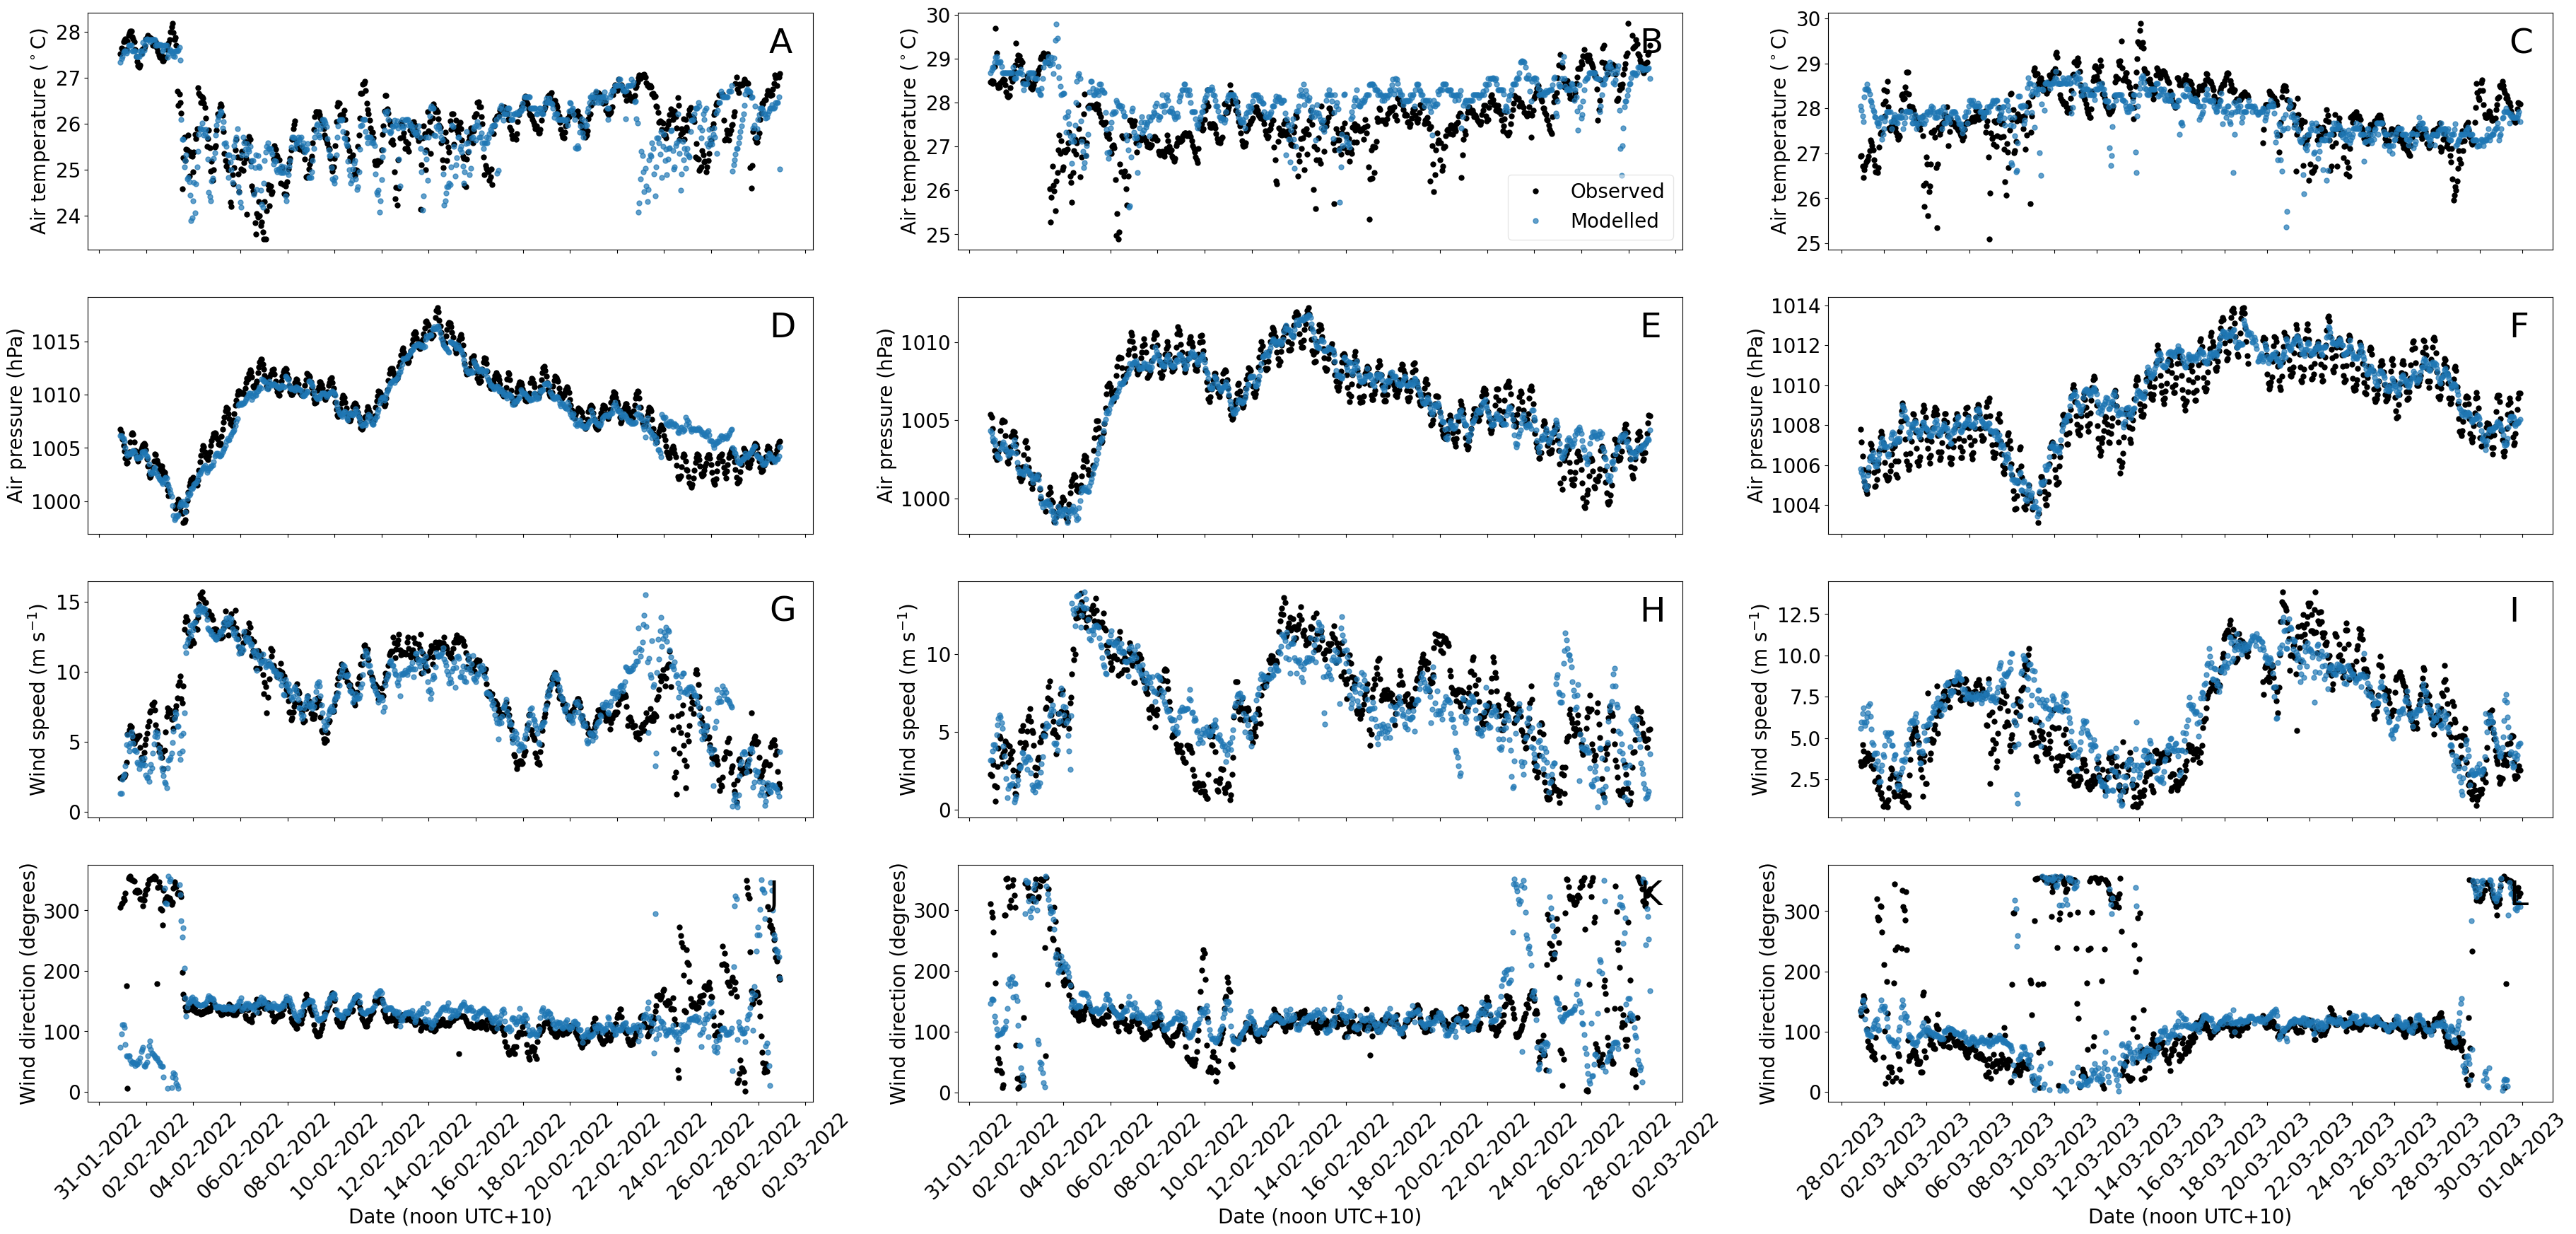


Heron Island 2022:
╒══════════════════════════════════════════════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤═════════╤═════════╤═════════╤═════════╤══════════╤════════════╤═════════╤═════════╤═══════════════╤════════╕
│ Variable                                             │ # points   │ Observed   │ Observed   │ Observed   │ Observed   │ Model   │ Model   │ Model   │ Model   │ Bias     │ Bias (%)   │ RMSE    │ NMBF    │ Spearmans r   │ p      │
│                                                      │            │ mean       │ min        │ max        │ SD         │ mean    │ min     │ max     │ SD      │          │            │         │         │               │        │
╞══════════════════════════════════════════════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═════════╪═════════╪═════════╪═════════╪══════════╪════════════╪═════════╪═════════╪═══════════════╪════════╡
│ Air_Temperature (m01s16i004)                         │

In [6]:
# Choose variables to plot
model_vars = ['m01s16i004', 'm01s00i408', 'WindSpeed', 'WindDir']
obs_vars = ['Air_Temperature', 'Air_Pressure', 'Wind_Speed_(Scalar_avg_10_min)', 'Wind_Direction_(Scalar_Average_10_Minutes)']
ylabels = ['Air temperature ($^\circ$C)', 'Air pressure (hPa)', 'Wind speed (m s$^{-1}$)', 'Wind direction (degrees)']
fout = fig_dir + 'Fig_Meteorology_AIMS_Heron_Davies.png'

# Format data for plotting
ws_heron_22['time'] = ws_heron_22['time'].dt.tz_localize(None)
ws_davies_22['time'] = ws_davies_22['time'].dt.tz_localize(None)
ws_davies_23['time'] = ws_davies_23['time'].dt.tz_localize(None)

model_H22, obs_H22 = align_times(access_heronWS_22, ws_heron_22)
model_D22, obs_D22 = align_times(access_daviesWS_22, ws_davies_22)
model_D23, obs_D23 = align_times(access_daviesWS_23, ws_davies_23)

model_H22['m01s16i004'] = model_H22['m01s16i004'] - 273.15   # K -> C
model_D22['m01s16i004'] = model_D22['m01s16i004'] - 273.15
model_D23['m01s16i004'] = model_D23['m01s16i004'] - 273.15

model_H22['m01s00i408'] = model_H22['m01s00i408'] /100       # Pa -> hPa
model_D22['m01s00i408'] = model_D22['m01s00i408'] /100
model_D23['m01s00i408'] = model_D23['m01s00i408'] /100

obs_H22['Wind_Speed_(Scalar_avg_30_min)'] = obs_H22['Wind_Speed_(Scalar_avg_30_min)'] *5/18   # km/hr -> m/s
obs_D22['Wind_Speed_(Scalar_avg_10_min)'] = obs_D22['Wind_Speed_(Scalar_avg_10_min)'] *5/18 
obs_D23['Wind_Speed_(Scalar_avg_10_min)'] = obs_D23['Wind_Speed_(Scalar_avg_10_min)'] *5/18

# Plot time-series
nrows = len(model_vars)
ncols = 3
fig, axs = plt.subplots(nrows, ncols, figsize=(15*ncols,5*nrows), sharex='col')

for iplt in range(nrows*ncols):
    irow = iplt // ncols
    icol = iplt % ncols 
    iax = axs[irow,icol]
    if icol == 0:
        model_tmp = model_H22
        obs_tmp = obs_H22
    elif icol == 1:
        model_tmp = model_D22
        obs_tmp = obs_D22
    elif icol == 2:
        model_tmp = model_D23
        obs_tmp = obs_D23
    start_dt = dt.datetime(model_tmp.time[0].dt.year.values, model_tmp.time[0].dt.month.values, model_tmp.time[0].dt.day.values, 2) # 02:00 UTC (12:00 UTC+10)
    ivar_model = model_vars[irow]
    ivar_obs = obs_vars[irow]
    if (icol==0) and (ivar_obs=='Wind_Speed_(Scalar_avg_10_min)'): # Handle different var names at Heron Island
        ivar_obs = 'Wind_Speed_(Scalar_avg_30_min)'
    if (icol==0) and (ivar_obs=='Wind_Direction_(Scalar_Average_10_Minutes)'):
        ivar_obs = 'Wind_Direction_(Scalar_Average_30_Minutes)'
    iax.plot(obs_tmp['time'], obs_tmp[ivar_obs], **obs_line, label='Observed')
    iax.plot(model_tmp['time'], model_tmp[ivar_model], **model_line2, label='Modelled')
    iax.set_ylabel(ylabels[irow])
    iax.annotate(plt_labels[iplt], xy=(0.1,0.1), xycoords='axes fraction', xytext=(0.94,0.83), color='black', fontsize=fontsize*1.75)
    iax.xaxis.set_major_formatter(date_form)
    xtick_rule = rrulewrapper(freq=DAILY, interval=2, byhour=2, dtstart=start_dt)
    xtick_loc = RRuleLocator(xtick_rule)
    iax.xaxis.set_major_locator(xtick_loc)
    if irow == nrows-1:
        iax.tick_params('x', labelrotation=45)
        iax.set_xlabel('Date (noon UTC+10)')
    
# Add legend and save
axs[0,1].legend(loc='best', framealpha=0.5)
plt.subplots_adjust(wspace=0.2)
plt.savefig(fout, bbox_inches='tight')
plt.show()

# Summary and bias metrics
print(f'\nHeron Island 2022:')
generate_summary_table(obs_H22, model_H22, ['Air_Temperature', 'Air_Pressure', 'Wind_Speed_(Scalar_avg_30_min)', 'Wind_Direction_(Scalar_Average_30_Minutes)'], model_vars)

print(f'\nDavies Reef 2022:')
generate_summary_table(obs_D22, model_D22, obs_vars, model_vars)

print(f'\nDavies Reef 2023:')
generate_summary_table(obs_D23, model_D23, obs_vars, model_vars)

### N10 and CCN

RRAP measurements:
* RV Guardian + RV Magnetic (Aerosol Lab + CloudCube) (2022)
* Heron Island Research Station (2023)

Activation diameter 73.90192361173878 nm
Activation diameter 73.90192361173878 nm
Activation diameter 73.90192361173878 nm
Activation diameter 73.90192361173878 nm
Timestamps aligned.
Timestamps aligned.
Timestamps aligned.
Timestamps aligned.
Timestamps aligned.
Timestamps aligned.
Timestamps aligned.
Timestamps aligned.


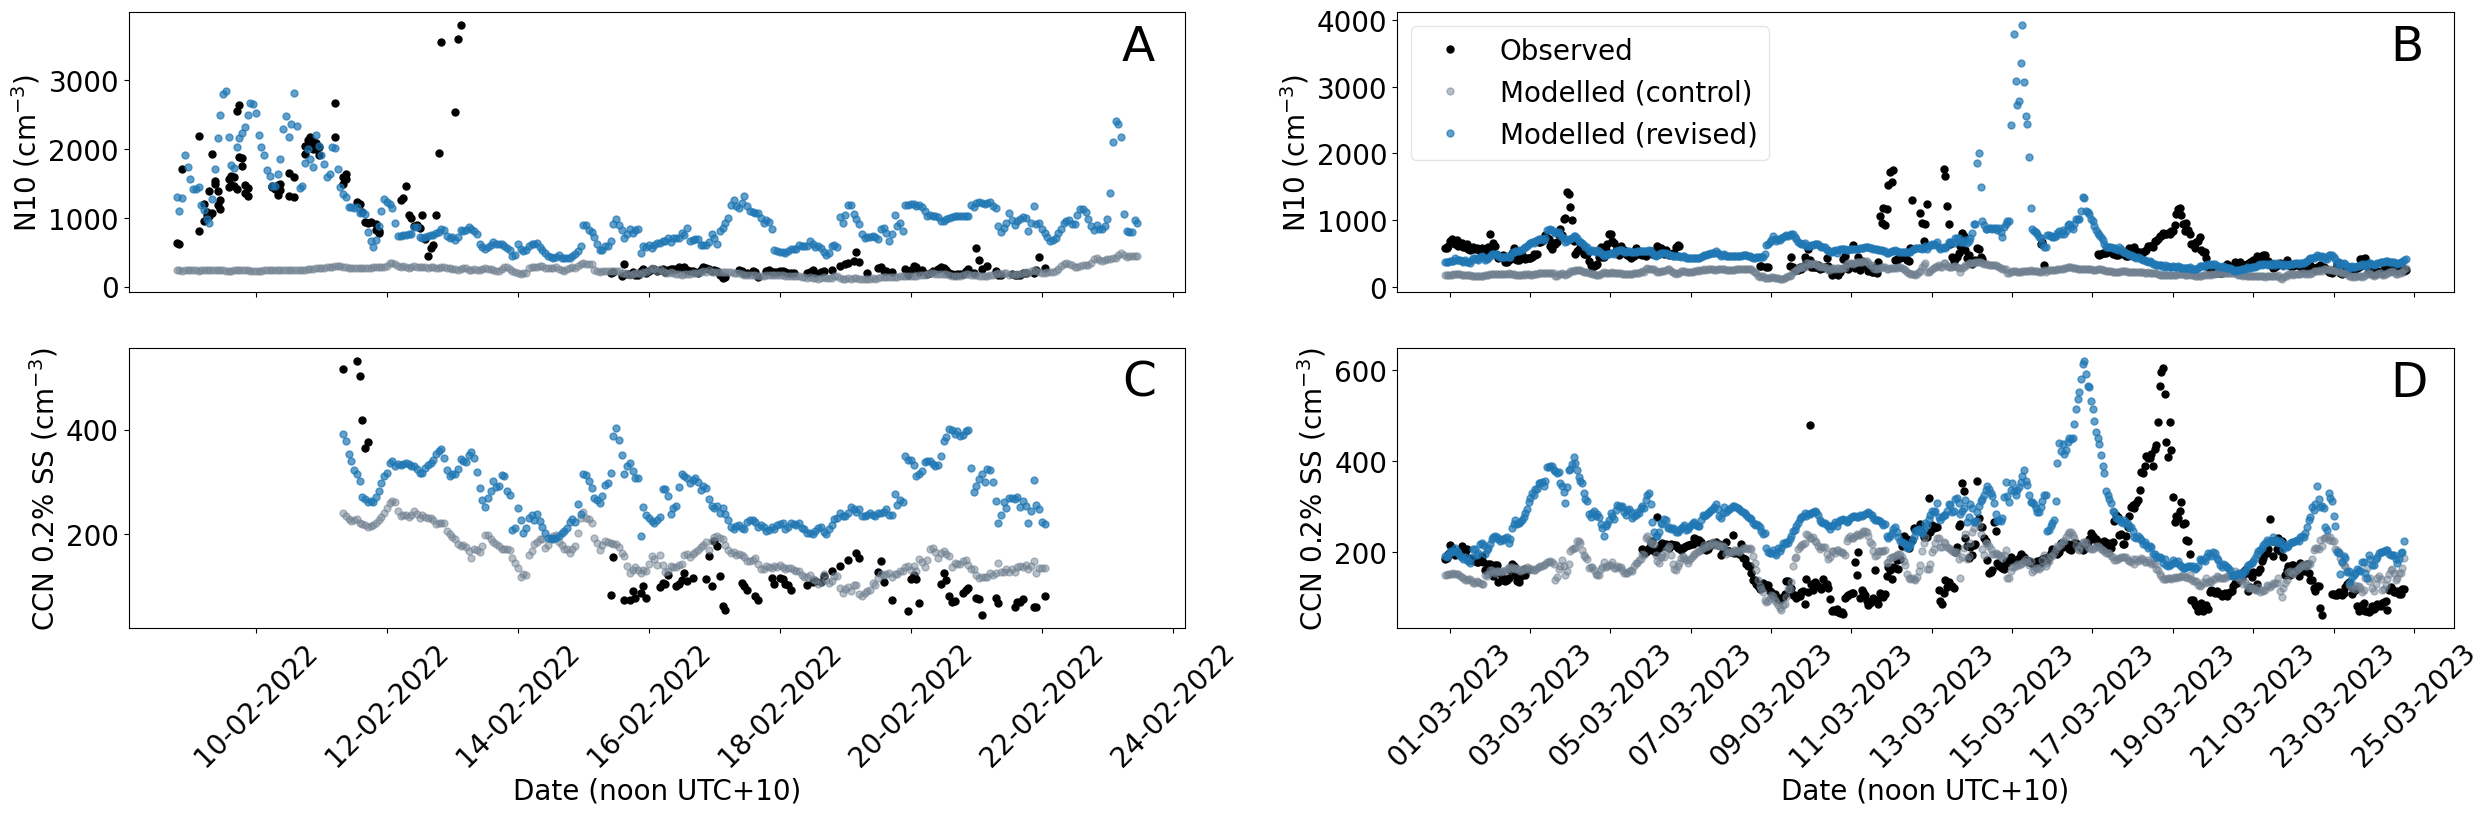


RV Guardian + RV Magnetic 2022:
╒══════════════════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤═════════╤═════════╤═════════╤═════════╤══════════╤════════════╤═════════╤═════════╤═══════════════╤════════╕
│ Variable                 │ # points   │ Observed   │ Observed   │ Observed   │ Observed   │ Model   │ Model   │ Model   │ Model   │ Bias     │ Bias (%)   │ RMSE    │ NMBF    │ Spearmans r   │ p      │
│                          │            │ mean       │ min        │ max        │ SD         │ mean    │ min     │ max     │ SD      │          │            │         │         │               │        │
╞══════════════════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═════════╪═════════╪═════════╪═════════╪══════════╪════════════╪═════════╪═════════╪═══════════════╪════════╡
│ Merged_N10 (N10)         │ 179        │ 673.4839   │ 129.9685   │ 3799.0317  │ 741.7167   │ 205.72  │ 110.418 │ 300.607 │ 48.607  │ -467.764 │ -39.4992  

In [6]:
ylabels = ['N10 (cm$^{-3}$)', 'CCN 0.2% SS (cm$^{-3}$)']
fout = fig_dir + 'Fig_N10_CCN_RRAP2022_RRAP2023.png'

# Filter Feb 2022 model N10 as per observations - CN >= 5000 cm-3 were considered 'polluted' (amongst other filters).
access_ctl_22_ship['N10'] = xr.where(access_ctl_22_ship['N10']<5000, access_ctl_22_ship['N10'], np.nan, keep_attrs=True)
access_rev_22_ship['N10'] = xr.where(access_rev_22_ship['N10']<5000, access_rev_22_ship['N10'], np.nan, keep_attrs=True)

# Calculate CCN at measured SS - Assuming 0.2% SS (~73.9 nm)
ss = 0.2
access_ctl_22_ship['CCN'] = calc_ccn(access_ctl_22_ship, ss)
access_rev_22_ship['CCN'] = calc_ccn(access_rev_22_ship, ss)
access_ctl_23_heron['CCN'] = calc_ccn(access_ctl_23_heron, ss)
access_rev_23_heron['CCN'] = calc_ccn(access_rev_23_heron, ss)

# Format data for plotting
model_N10_22, obs_N10_22 = align_times(access_ctl_22_ship, rrap_22_N10)
model_N10_22_rev, dummy = align_times(access_rev_22_ship, rrap_22_N10)

model_N10_23, obs_N10_23 = align_times(access_ctl_23_heron, rrap_23_N10)
model_N10_23_rev, dummy = align_times(access_rev_23_heron, rrap_23_N10)

model_CCN_22, obs_CCN_22 = align_times(access_ctl_22_ship, rrap_22_ccn)
model_CCN_22_rev, dummy = align_times(access_rev_22_ship, rrap_22_ccn)

model_CCN_23, obs_CCN_23 = align_times(access_ctl_23_heron, rrap_23_ccn)
model_CCN_23_rev, dummy = align_times(access_rev_23_heron, rrap_23_ccn)

# Plot time-series
pltdata = {(0, 0): (obs_N10_22, model_N10_22, model_N10_22_rev, 'CN_guard_cloud', 'N10'),
           (0, 1): (obs_N10_23, model_N10_23, model_N10_23_rev, 'conc', 'N10'),
           (1, 0): (obs_CCN_22, model_CCN_22, model_CCN_22_rev, 'conc', 'CCN'),
           (1, 1): (obs_CCN_23, model_CCN_23, model_CCN_23_rev, 'conc', 'CCN')}

nrows = 2
ncols = 2
fig, axs = plt.subplots(nrows, ncols, figsize=(15*ncols,4*nrows), sharex='col')

for iplt in range(nrows*ncols):
    irow = iplt // ncols
    icol = iplt % ncols 
    iax = axs[irow,icol]
    obs_tmp, model_ctl, model_rev, ivar_obs, ivar_model = pltdata[irow,icol]

    iax.plot(obs_tmp['time'], obs_tmp[ivar_obs], **obs_line, label='Observed')
    if (ivar_obs == 'CN_guard_cloud'): # ship N10 data
        iax.plot(obs_tmp['time'], obs_tmp['CN_mag'], **obs_line, label='') # add CN_mag to CN_guard_cloud timeseries
    iax.plot(model_ctl['time'], model_ctl[ivar_model], **model_line1, label='Modelled (control)')
    iax.plot(model_rev['time'], model_rev[ivar_model], **model_line2, label='Modelled (revised)')
    iax.set_ylabel(ylabels[irow])
    iax.annotate(plt_labels[iplt], xy=(0.1,0.1), xycoords='axes fraction', xytext=(0.94,0.83), color='black', fontsize=fontsize*1.75)
    iax.xaxis.set_major_formatter(date_form)
    start_dt = dt.datetime(model_ctl.time[0].dt.year.values, model_ctl.time[0].dt.month.values, model_ctl.time[0].dt.day.values, 2) # 02:00 UTC (12:00 UTC+10)
    xtick_rule = rrulewrapper(freq=DAILY, interval=2, byhour=2, dtstart=start_dt)
    xtick_loc = RRuleLocator(xtick_rule)
    iax.xaxis.set_major_locator(xtick_loc)
    if irow == nrows-1:
        iax.tick_params('x', labelrotation=45)
        iax.set_xlabel('Date (noon UTC+10)')
    
# Add legend and save
axs[0,1].legend(loc='upper left', framealpha=0.5)
plt.subplots_adjust(wspace=0.2)
plt.savefig(fout, bbox_inches='tight')
plt.show()

# Summary and bias metrics
print(f'\nRV Guardian + RV Magnetic 2022:')
obs_N10_22['Merged_N10'] = obs_N10_22['CN_guard_cloud'].fillna(obs_N10_22['CN_mag'])
generate_summary_table(obs_N10_22, model_N10_22, ['Merged_N10'], ['N10'], model_ds2=model_N10_22_rev)
generate_summary_table(obs_CCN_22, model_CCN_22, ['conc'], ['CCN'], model_ds2=model_CCN_22_rev)

print(f'\nHeron Island Research Station 2023:')
generate_summary_table(obs_N10_23, model_N10_23, ['conc'], ['N10'], model_ds2=model_N10_23_rev)
generate_summary_table(obs_CCN_23, model_CCN_23, ['conc'], ['CCN'], model_ds2=model_CCN_23_rev)

### Aerosol size distribution

RRAP measurements:
* Heron Island Research Station (2023)

Timestamps aligned.
Timestamps aligned.
Check that size bins align:


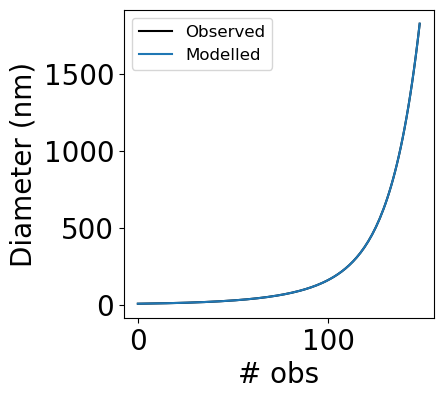

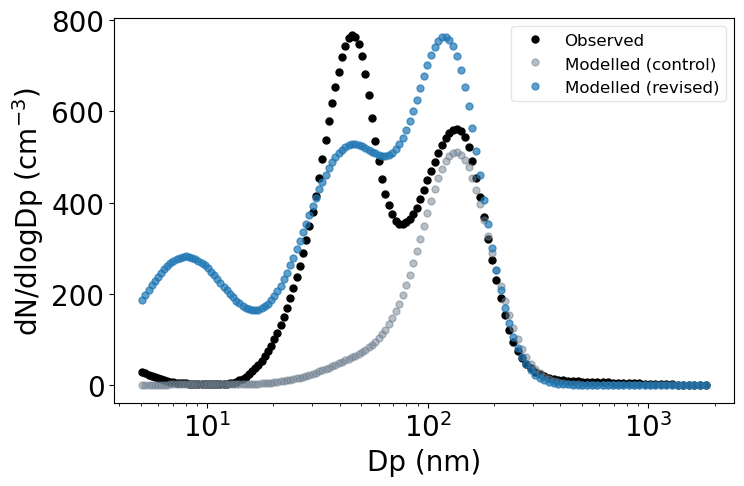

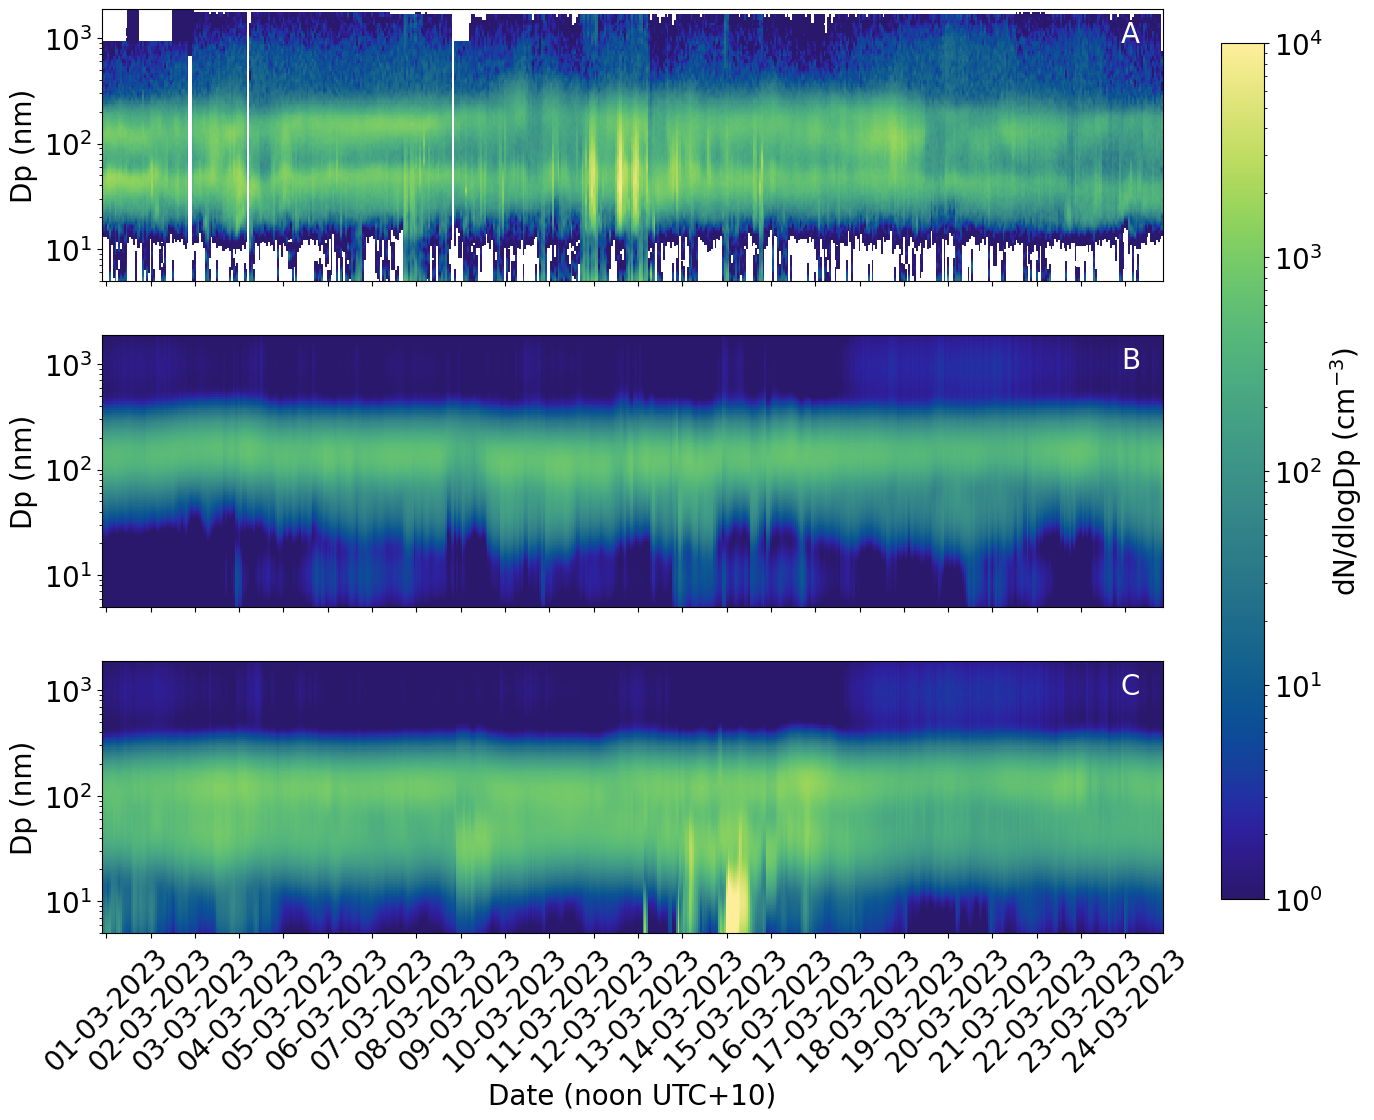

In [13]:
fout1 = fig_dir + 'Fig_Aerosol_SizeDist_RRAP2023_tavg.png'
fout2 = fig_dir + 'Fig_Aerosol_SizeDist_RRAP2023_tseries.png'

# Format data for plotting
model_SD, obs_SD = align_times(access_ctl_23_heron, rrap_23_SD)
model_SD_rev, dummy = align_times(access_rev_23_heron, rrap_23_SD)

# Format measurements
n_obs = len(obs_SD)
df_headers = obs_SD.columns.tolist()
idx_diam1 = df_headers.index('Dia1')
idx_diam2 = df_headers.index('Dia150')
idx_conc1 = df_headers.index('Conc1')
idx_conc2 = df_headers.index('Conc150')
obs_diam = np.array(obs_SD.iloc[0,idx_diam1:idx_diam2]).astype(float) # array of particle sizes (1 x diameter)
obs_conc = np.zeros((len(obs_diam), n_obs))
for t in range(0,n_obs):
    obs_conc[:,t] = obs_SD.iloc[t,idx_conc1:idx_conc2] # array of particle concentration (diameter x time)
is_missing = np.isnan(obs_diam) # Remove NaNs
obs_diam = obs_diam[~is_missing]
obs_conc = obs_conc[~is_missing, :]
    
# Format model output
bins = obs_diam.copy() *1e-9 # diameters in m
model_SD = construct_size_dist(model_SD, bins, l_setbins=True)
model_SD_rev = construct_size_dist(model_SD_rev, bins, l_setbins=True)

# Check that model size bins align w. measured
print('Check that size bins align:')
fig, ax = plt.subplots(1, 1, figsize=(4,4))
ax.plot(obs_diam, 'k')
ax.plot(model_SD['diameter'])
ax.set(xlabel='# obs', ylabel='Diameter (nm)')
ax.legend(['Observed','Modelled'], loc='best', fontsize=12)

# Time-averaged size distribution
obs_conc_2d = np.nanmean(obs_conc, axis=1)
model_ctl_2d = model_SD.copy().mean(dim='time')
model_rev_2d = model_SD_rev.copy().mean(dim='time')
fig, ax = plt.subplots(1,1,figsize=(8,5))
ax.plot(obs_diam, obs_conc_2d, **obs_line, label='Observed')
ax.plot(model_ctl_2d['diameter'], model_ctl_2d['sizedist'], **model_line1, label='Modelled (control)')
ax.plot(model_rev_2d['diameter'], model_rev_2d['sizedist'], **model_line2, label='Modelled (revised)')
ax.set(xlabel='Dp (nm)', ylabel='dN/dlogDp (cm$^{-3}$)')
ax.set_xscale('log')
ax.legend(loc='best', framealpha=0.5, fontsize=12)
plt.savefig(fout1, bbox_inches='tight')

# Time-series
cmap = cmocean.cm.haline
cNorm = colors.LogNorm(vmin=1, vmax=10000)
nplts = 3
plt_height = 4*nplts
plt_width = 15
im_ratio = plt_height/plt_width
fig, axs = plt.subplots(nplts,1,figsize=(plt_width,plt_height),sharex=True)
ax0 = axs[0].pcolormesh(obs_SD['time'], obs_diam, obs_conc, shading='auto', norm=cNorm, cmap=cmap)
ax1 = axs[1].pcolormesh(model_SD['time'], model_SD['diameter'], model_SD['sizedist'], shading='auto', norm=cNorm, cmap=cmap)
ax2 = axs[2].pcolormesh(model_SD_rev['time'], model_SD_rev['diameter'], model_SD_rev['sizedist'], shading='auto', norm=cNorm, cmap=cmap)
for iplt in range(nplts):
    axs[iplt].set_yscale('log')
    axs[iplt].annotate(plt_labels[iplt], xy=(0.1,0.1), xycoords='axes fraction', xytext=(0.96,0.88), color='white', fontsize=20)
    axs[iplt].set(ylabel='Dp (nm)')
    axs[iplt].tick_params(axis='both', which='major')
    axs[iplt].xaxis.set_major_formatter(date_form)
    axs[iplt].xaxis.set_major_locator(mdates.HourLocator(byhour=2))
    axs[iplt].tick_params('x', labelrotation=45)
axs[-1].set(xlabel='Date (noon UTC+10)')
plt.colorbar(ax1, ax=axs[:], fraction=0.046*im_ratio, orientation='vertical').set_label('dN/dlogDp (cm$^{-3}$)')
plt.savefig(fout2, bbox_inches='tight')

### Aerosol composition

RRAP measurements:
* Heron Island Research Station (2023)

Timestamps aligned.
Timestamps aligned.


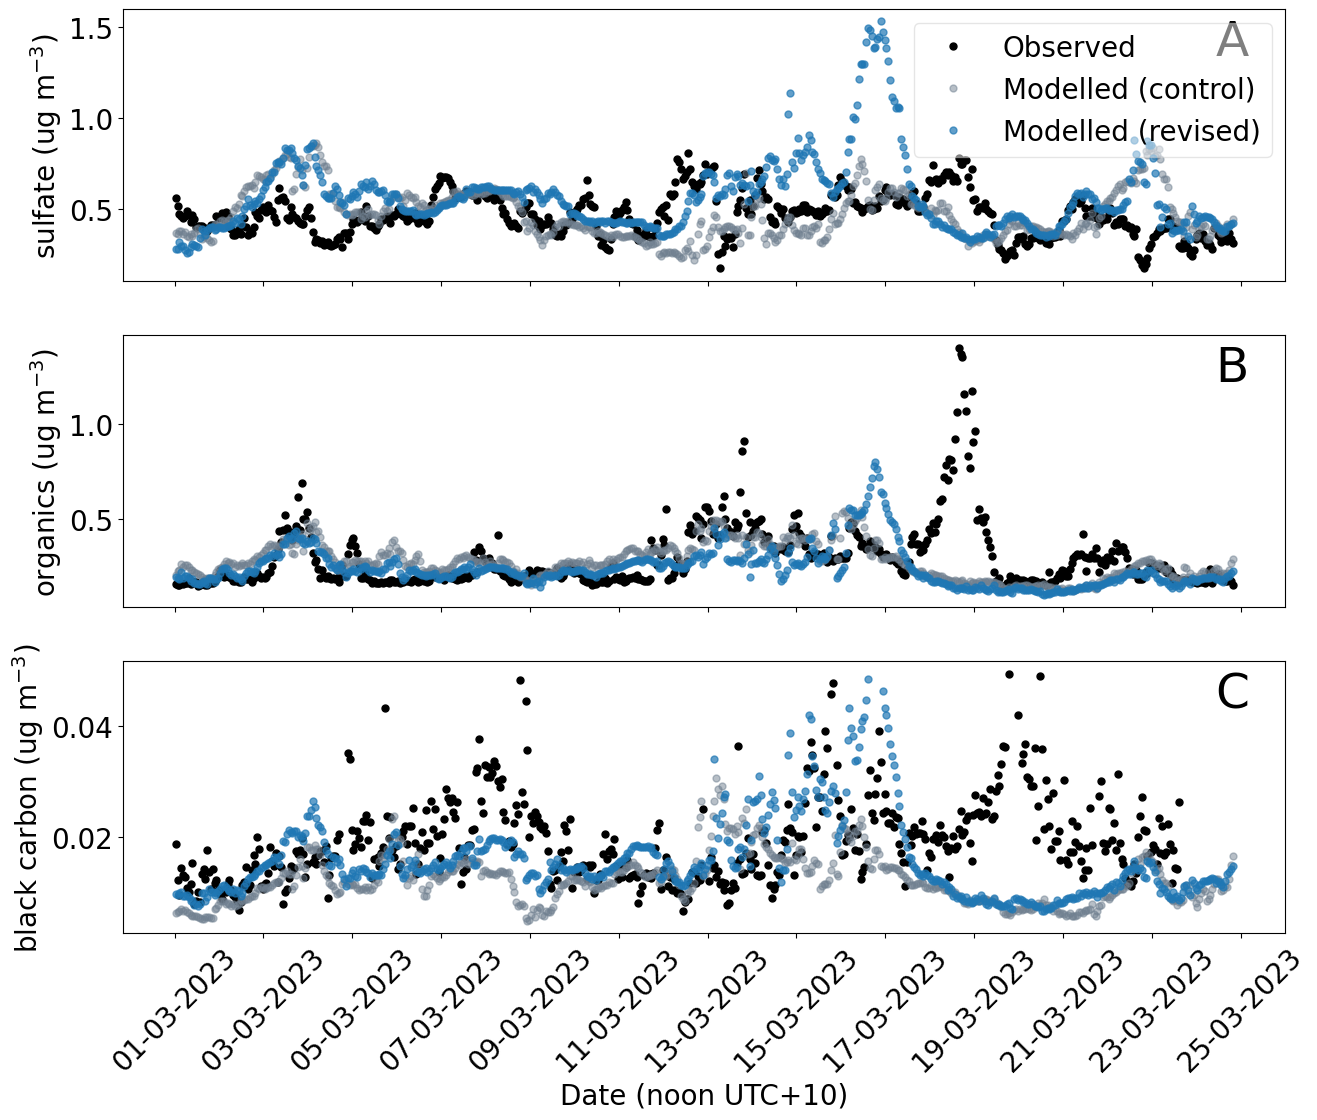


Heron Island 2023:
╒═══════════════════════════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤═════════╤═════════╤═════════╤═════════╤═════════╤════════════╤════════╤═════════╤═══════════════╤════════╕
│ Variable                          │ # points   │ Observed   │ Observed   │ Observed   │ Observed   │ Model   │ Model   │ Model   │ Model   │ Bias    │ Bias (%)   │ RMSE   │ NMBF    │ Spearmans r   │ p      │
│                                   │            │ mean       │ min        │ max        │ SD         │ mean    │ min     │ max     │ SD      │         │            │        │         │               │        │
╞═══════════════════════════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═════════╪═════════╪═════════╪═════════╪═════════╪════════════╪════════╪═════════╪═══════════════╪════════╡
│ HRSO4 (aerosol_sulf_mass)         │ 572        │ 0.4661     │ 0.1716     │ 0.8046     │ 0.1172     │ 0.4717  │ 0.2199  │ 0.8605  │ 0.1344 

In [11]:
# Choose variables to plot
model_vars = ['aerosol_sulf_mass', 'aerosol_oc_mass', 'aerosol_bc_mass']
obs_vars = ['HRSO4', 'HROrg', 'BC']
ylabels = ['sulfate (ug m$^{-3}$)', 'organics (ug m$^{-3}$)', 'black carbon (ug m$^{-3}$)']
fout = fig_dir + 'Fig_Aerosol_composition_RRAP2023.png'

# Format data for plotting

# Put black carbon Aethalometer measurements into AMS dataset
combined_obs = rrap_23_AMS.copy()
combined_obs['BC'] = rrap_23_BC['BC2;'] *1e-3 # ng/m3 –> ug/m3

# Convert model OC to organic matter (assumes OM:OC ratio of 1.4)
access_ctl_23_heron['aerosol_oc_mass'] = access_ctl_23_heron['aerosol_oc_mass'] *1.4
access_rev_23_heron['aerosol_oc_mass'] = access_rev_23_heron['aerosol_oc_mass'] *1.4

# Filter measured BC >= 50 ng/m3 (potential ship exhaust)
combined_obs['BC'] = np.where(combined_obs['BC']>=0.05, np.nan, combined_obs['BC'])
access_ctl_23_heron['aerosol_bc_mass'] = xr.where(access_ctl_23_heron['aerosol_bc_mass']>=0.05, np.nan, access_ctl_23_heron['aerosol_bc_mass']) # filter model BC as above
access_rev_23_heron['aerosol_bc_mass'] = xr.where(access_rev_23_heron['aerosol_bc_mass']>=0.05, np.nan, access_rev_23_heron['aerosol_bc_mass']) 

# Align timestamps
model_ctl, obs = align_times(access_ctl_23_heron, combined_obs)
model_rev, dummy = align_times(access_rev_23_heron, combined_obs)

# Plot time-series
nrows = len(model_vars)
ncols = 1
fig, axs = plt.subplots(nrows, ncols, figsize=(15*ncols,4*nrows), sharex='col')

for iplt in range(nrows*ncols):
    iax = axs[iplt]
    start_dt = dt.datetime(model_ctl.time[0].dt.year.values, model_ctl.time[0].dt.month.values, model_ctl.time[0].dt.day.values, 2) # 02:00 UTC (12:00 UTC+10)
    ivar_model = model_vars[iplt]
    ivar_obs = obs_vars[iplt]
    iax.plot(obs['time'], obs[ivar_obs], **obs_line, label='Observed')
    iax.plot(model_ctl['time'], model_ctl[ivar_model], **model_line1, label='Modelled (control)')
    iax.plot(model_rev['time'], model_rev[ivar_model], **model_line2, label='Modelled (revised)')
    iax.set_ylabel(ylabels[iplt])
    iax.annotate(plt_labels[iplt], xy=(0.1,0.1), xycoords='axes fraction', xytext=(0.94,0.83), color='black', fontsize=fontsize*1.75)
    iax.xaxis.set_major_formatter(date_form)
    xtick_rule = rrulewrapper(freq=DAILY, interval=2, byhour=2, dtstart=start_dt)
    xtick_loc = RRuleLocator(xtick_rule)
    iax.xaxis.set_major_locator(xtick_loc)
    if iplt == nrows-1:
        iax.tick_params('x', labelrotation=45)
        iax.set_xlabel('Date (noon UTC+10)')
    
# Add legend and save
axs[0].legend(loc='best', framealpha=0.5)
plt.subplots_adjust(wspace=0.2)
plt.savefig(fout, bbox_inches='tight')
plt.show()

# Summary and bias metrics
print(f'\nHeron Island 2023:')
generate_summary_table(obs, model_ctl, obs_vars, model_vars, model_ds2=model_rev)

### AOD

AERONET Lucinda measurements:
* AOD at 551 nm (2022)
* AOD at 523 nm (2023)


Timestamps aligned.
Timestamps aligned.
Timestamps aligned.
Timestamps aligned.


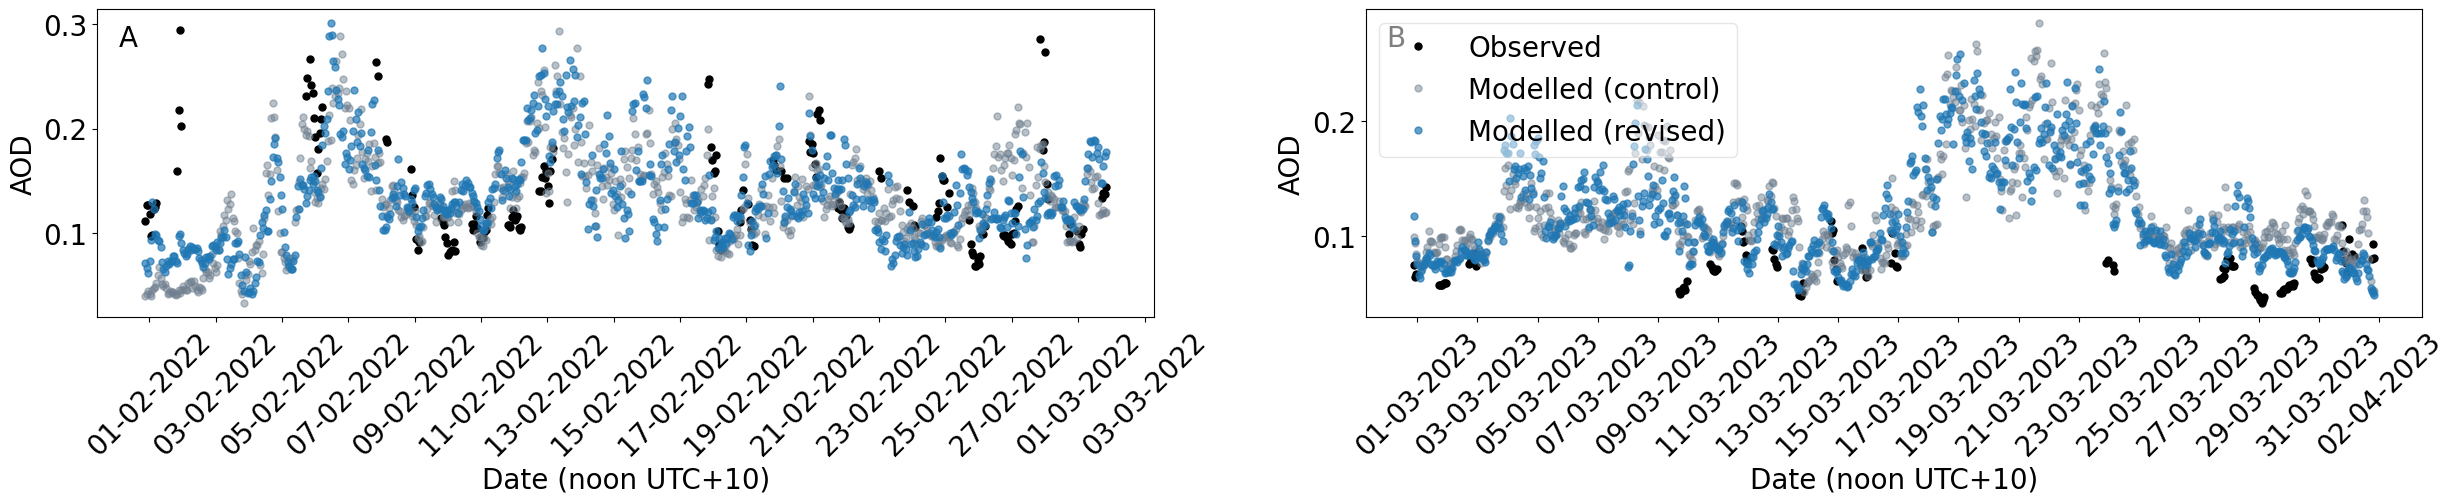


AERONET AOD 2022:
╒═══════════════════════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤═════════╤═════════╤═════════╤═════════╤═════════╤════════════╤════════╤═════════╤═══════════════╤════════╕
│ Variable                      │ # points   │ Observed   │ Observed   │ Observed   │ Observed   │ Model   │ Model   │ Model   │ Model   │ Bias    │ Bias (%)   │ RMSE   │ NMBF    │ Spearmans r   │ p      │
│                               │            │ mean       │ min        │ max        │ SD         │ mean    │ min     │ max     │ SD      │         │            │        │         │               │        │
╞═══════════════════════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═════════╪═════════╪═════════╪═════════╪═════════╪════════════╪════════╪═════════╪═══════════════╪════════╡
│ AOD_551nm (Total_AOD)         │ 179        │ 0.1362     │ 0.0685     │ 0.294      │ 0.0477     │ 0.1264  │ 0.0397  │ 0.2556  │ 0.0403  │ -0.0098 │ 0.6899  

In [9]:
# Choose variables to plot
model_var = 'Total_AOD'
obs_var = ['AOD_551nm', 'AOD_532nm']
ylabel = 'AOD'
fout = fig_dir + 'Fig_AOD_AERONET.png'

# Format data for plotting
model_ctl_22, obs_22 = align_times(access_ctl_22_aeronet, aeronet_22)
model_rev_22, dummy = align_times(access_rev_22_aeronet, aeronet_22)

model_ctl_23, obs_23 = align_times(access_ctl_23_aeronet, aeronet_23)
model_rev_23, dummy = align_times(access_rev_23_aeronet, aeronet_23)

# Remove invalid values (-9999)
obs_22['AOD_551nm'] = np.where(obs_22['AOD_551nm']<0, np.nan, obs_22['AOD_551nm'])
obs_23['AOD_532nm'] = np.where(obs_23['AOD_532nm']<0, np.nan, obs_23['AOD_532nm'])

# Plot time-series
nrows = 1
ncols = 2
fig, axs = plt.subplots(nrows, ncols, figsize=(15*ncols,4*nrows))

for iplt in range(nrows*ncols):
    iax = axs[iplt]
    if iplt == 0:
        model_ctl_tmp = model_ctl_22
        model_rev_tmp = model_rev_22
        obs_tmp = obs_22
    elif iplt == 1:
        model_ctl_tmp = model_ctl_23
        model_rev_tmp = model_rev_23
        obs_tmp = obs_23
    start_dt = dt.datetime(model_ctl_tmp.time[0].dt.year.values, model_ctl_tmp.time[0].dt.month.values, model_ctl_tmp.time[0].dt.day.values, 2)
    model_ivar = model_var
    obs_ivar = obs_var[iplt]
    iax.plot(obs_tmp['time'], obs_tmp[obs_ivar], **obs_line, label='Observed')
    iax.plot(model_ctl_tmp['time'], model_ctl_tmp[model_ivar], **model_line1, label='Modelled (control)')
    iax.plot(model_rev_tmp['time'], model_rev_tmp[model_ivar], **model_line2, label='Modelled (revised)')
    iax.set_ylabel(ylabel)
    iax.annotate(plt_labels[iplt], xy=(0.1,0.1), xycoords='axes fraction', xytext=(0.02,0.88), color='black', fontsize=fontsize)
    iax.xaxis.set_major_formatter(date_form)
    xtick_rule = rrulewrapper(freq=DAILY, interval=2, byhour=2, dtstart=start_dt)
    xtick_loc = RRuleLocator(xtick_rule)
    iax.xaxis.set_major_locator(xtick_loc)
    iax.tick_params('x', labelrotation=45)
    iax.set_xlabel('Date (noon UTC+10)')
    
# Add legend and save
axs[1].legend(loc='best', framealpha=0.5)
plt.subplots_adjust(wspace=0.2)
plt.savefig(fout, bbox_inches='tight')
plt.show()

# Summary and bias metrics
print(f'\nAERONET AOD 2022:')
generate_summary_table(obs_22, model_ctl_22, [obs_var[0]], [model_var], model_ds2=model_rev_22)

print(f'\nAERONET AOD 2023:')
generate_summary_table(obs_23, model_ctl_23, [obs_var[1]], [model_var], model_ds2=model_rev_23)

### Seawater temperature

EcoRRAP measurements for 2022 and 2023 @ Davies Reef:
* Lagoon flat (2 m)
* Reef front shallow (5 m)
* Reef front deep (13 m)

EcoRRAP measurements for 2022 and 2023 @ Heron Island:
* Lagoon shallow (5 m, 2022 only)
* Reef front shallow (5 m)
* Reef front deep (14.5 m, 2023 only)

Timestamps aligned.
Timestamps aligned.
Timestamps aligned.
Timestamps aligned.
Timestamps aligned.
Timestamps aligned.
Timestamps aligned.
Timestamps aligned.
Timestamps aligned.
Timestamps aligned.


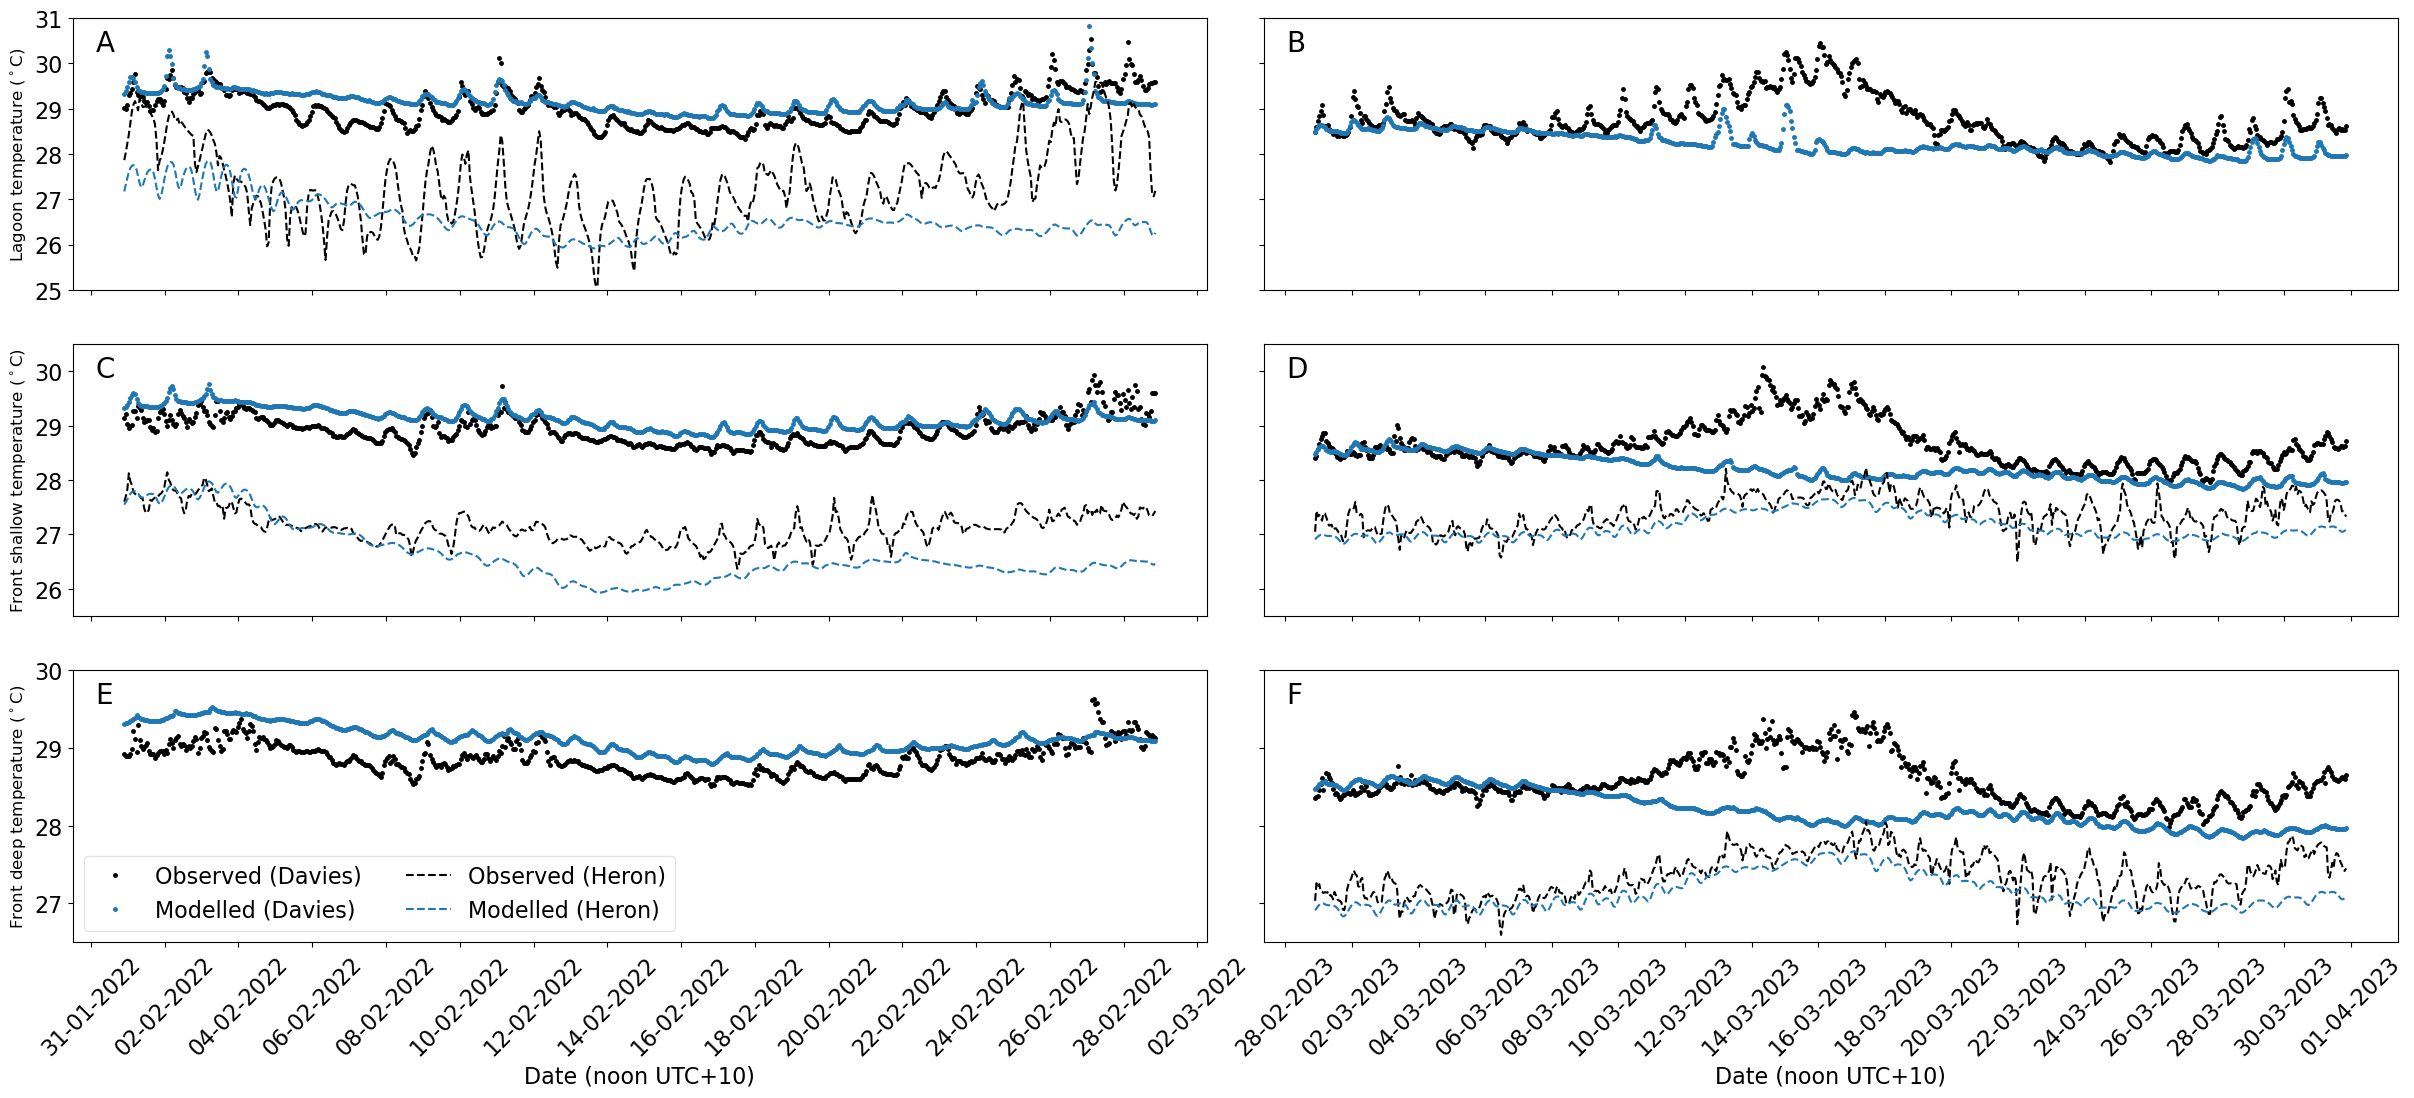


Davies Reef 2022:
╒════════════════════════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤═════════╤═════════╤═════════╤═════════╤════════╤════════════╤════════╤════════╤═══════════════╤════════╕
│ Variable                       │ # points   │ Observed   │ Observed   │ Observed   │ Observed   │ Model   │ Model   │ Model   │ Model   │ Bias   │ Bias (%)   │ RMSE   │ NMBF   │ Spearmans r   │ p      │
│                                │            │ mean       │ min        │ max        │ SD         │ mean    │ min     │ max     │ SD      │        │            │        │        │               │        │
╞════════════════════════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═════════╪═════════╪═════════╪═════════╪════════╪════════════╪════════╪════════╪═══════════════╪════════╡
│ LF_TEMP_degrees_Celsius (temp) │ 672        │ 29.0117    │ 28.3335    │ 30.5281    │ 0.3962     │ 29.1659 │ 28.7931 │ 30.8342 │ 0.2397  │ 0.1542 │ 0.5423     │

In [10]:
fout = fig_dir + 'SeawaterTemp_EcoRRAP.png'

plt.rcParams.update({'font.size':16, 'mathtext.default':'regular'})

# Format data for plotting
ER_Davies_22['time'] = ER_Davies_22['time'].dt.tz_localize(None)
ER_Davies_23['time'] = ER_Davies_23['time'].dt.tz_localize(None)
ER_Heron_22['time'] = ER_Heron_22['time'].dt.tz_localize(None)
ER_Heron_23['time'] = ER_Heron_23['time'].dt.tz_localize(None)

model_DLF_22, obs_D22 = align_times(ems_davies_22_LF, ER_Davies_22)
model_DFS_22, dummy = align_times(ems_davies_22_FS, ER_Davies_22)
model_DFD_22, dummy = align_times(ems_davies_22_FD, ER_Davies_22)

model_DLF_23, obs_D23 = align_times(ems_davies_23_LF, ER_Davies_23)
model_DFS_23, dummy = align_times(ems_davies_23_FS, ER_Davies_23)
model_DFD_23, dummy = align_times(ems_davies_23_FD, ER_Davies_23)

model_HLS_22, obs_H22 = align_times(ems_heron_22_LS, ER_Heron_22)
model_HFS_22, dummy = align_times(ems_heron_22_FS, ER_Heron_22)

model_HFS_23, obs_H23 = align_times(ems_heron_23_FS, ER_Heron_23)
model_HFD_23, dummy = align_times(ems_heron_23_FD, ER_Heron_23)

# Plot time-series
nrows = 3
ncols = 2
fig, axs = plt.subplots(nrows,ncols,figsize=(15*ncols,4*nrows),sharex='col',sharey='row')

obs_Dline = {'linestyle':'', 'color':'k', 'marker':'.', 'markersize':5, 'linewidth':1.5}    # Davies Reef     
obs_Hline = {'linestyle':'--', 'color':'k', 'linewidth':1.5}                                # Heron Island
model_Dline = {'linestyle':'', 'color':'C0', 'marker':'.', 'markersize':5, 'linewidth':1.5}                   
model_Hline = {'linestyle':'--', 'color':'C0', 'linewidth':1.5}  

# Lagoon flat / shallow
axs[0,0].plot(obs_D22['time'], obs_D22['LF_TEMP_degrees_Celsius'], **obs_Dline, label='Observed (Davies)')
axs[0,0].plot(model_DLF_22['time'], model_DLF_22['temp'], **model_Dline, label='Modelled (Davies)')
axs[0,0].plot(obs_H22['time'], obs_H22['LS_TEMP_degrees_Celsius'], **obs_Hline, label='Observed (Heron)')
axs[0,0].plot(model_HLS_22['time'], model_HLS_22['temp'], **model_Hline, label='Modelled (Heron)')
axs[0,0].set_ylabel('Lagoon temperature ($^\circ$C)', fontsize=12)

axs[0,1].plot(obs_D23['time'], obs_D23['LF_TEMP_degrees_Celsius'], **obs_Dline, label='Observed (Davies)')
axs[0,1].plot(model_DLF_23['time'], model_DLF_23['temp'], **model_Dline, label='Modelled (Davies)')
axs[0,1].set_ylim([25,31])

# Reef front shallow
axs[1,0].plot(obs_D22['time'], obs_D22['FS_TEMP_degrees_Celsius'], **obs_Dline, label='Observed (Davies)')
axs[1,0].plot(model_DFS_22['time'], model_DFS_22['temp'], **model_Dline, label='Modelled (Davies)')
axs[1,0].plot(obs_H22['time'], obs_H22['FS_TEMP_degrees_Celsius'], **obs_Hline, label='Observed (Heron)')
axs[1,0].plot(model_HFS_22['time'], model_HFS_22['temp'], **model_Hline, label='Modelled (Heron)')
axs[1,0].set_ylabel('Front shallow temperature ($^\circ$C)', fontsize=12)

axs[1,1].plot(obs_D23['time'], obs_D23['FS_TEMP_degrees_Celsius'], **obs_Dline, label='Observed (Davies)')
axs[1,1].plot(model_DFS_23['time'], model_DFS_23['temp'], **model_Dline, label='Modelled (Davies)')
axs[1,1].plot(obs_H23['time'], obs_H23['FS_TEMP_degrees_Celsius'], **obs_Hline, label='Observed (Heron)')
axs[1,1].plot(model_HFS_23['time'], model_HFS_23['temp'], **model_Hline, label='Modelled (Heron)')
axs[1,1].set_ylim([25.5,30.5])

# Reef front deep
axs[2,0].plot(obs_D22['time'], obs_D22['FD_TEMP_degrees_Celsius'], **obs_Dline, label='Observed (Davies)')
axs[2,0].plot(model_DFD_22['time'], model_DFD_22['temp'], **model_Dline, label='Modelled (Davies)')
axs[2,0].set_ylabel('Front deep temperature ($^\circ$C)', fontsize=12)

axs[2,1].plot(obs_D23['time'], obs_D23['FD_TEMP_degrees_Celsius'], **obs_Dline, label='Observed (Davies)')
axs[2,1].plot(model_DFD_23['time'], model_DFD_23['temp'], **model_Dline, label='Modelled (Davies)')
axs[2,1].plot(obs_H23['time'], obs_H23['FD_TEMP_degrees_Celsius'], **obs_Hline, label='Observed (Heron)')
axs[2,1].plot(model_HFD_23['time'], model_HFD_23['temp'], **model_Hline, label='Modelled (Heron)')
axs[2,1].set_ylim([26.5,30])

start_dt_22 = dt.datetime(model_DFD_22.time[0].dt.year.values, model_DFD_22.time[0].dt.month.values, model_DFD_22.time[0].dt.day.values, 2)
xtick_rule = rrulewrapper(freq=DAILY, interval=2, byhour=2, dtstart=start_dt_22)
xtick_loc = RRuleLocator(xtick_rule)
axs[2,0].xaxis.set_major_formatter(date_form)
axs[2,0].xaxis.set_major_locator(xtick_loc)

start_dt_23 = dt.datetime(model_DFD_23.time[0].dt.year.values, model_DFD_23.time[0].dt.month.values, model_DFD_23.time[0].dt.day.values, 2)
xtick_rule = rrulewrapper(freq=DAILY, interval=2, byhour=2, dtstart=start_dt_23)
xtick_loc = RRuleLocator(xtick_rule)
axs[2,1].xaxis.set_major_formatter(date_form)
axs[2,1].xaxis.set_major_locator(xtick_loc)

for iplt in range(nrows*ncols):
    irow = iplt // ncols
    icol = iplt % ncols 
    iax = axs[irow,icol]
    iax.annotate(plt_labels[iplt], xy=(0.1,0.1), xycoords='axes fraction', xytext=(0.02,0.88), color='black', fontsize=fontsize)
    if irow == nrows-1:
        iax.tick_params('x', labelrotation=45)
        iax.set_xlabel('Date (noon UTC+10)')
    
# Add legend
handles = []
labels = []
for iax in axs.flat:
    h, l = iax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)
by_label = dict(zip(labels, handles))
axs[2,0].legend(by_label.values(), by_label.keys(), loc='best', framealpha=0.5, ncols=2)

# Save
plt.subplots_adjust(wspace=0.05, hspace=0.2)
plt.savefig(fout, bbox_inches='tight')
plt.show()

# Summary and bias metrics
print(f'\nDavies Reef 2022:')
generate_summary_table(obs_D22, model_DLF_22, ['LF_TEMP_degrees_Celsius'], ['temp'])
generate_summary_table(obs_D22, model_DFS_22, ['FS_TEMP_degrees_Celsius'], ['temp'])
generate_summary_table(obs_D22, model_DFD_22, ['FD_TEMP_degrees_Celsius'], ['temp'])

print(f'\nDavies Reef 2023:')
generate_summary_table(obs_D23, model_DLF_23, ['LF_TEMP_degrees_Celsius'], ['temp'])
generate_summary_table(obs_D23, model_DFS_23, ['FS_TEMP_degrees_Celsius'], ['temp'])
generate_summary_table(obs_D23, model_DFD_23, ['FD_TEMP_degrees_Celsius'], ['temp'])

print(f'\nHeron Island 2022:')
generate_summary_table(obs_H22, model_HLS_22, ['LS_TEMP_degrees_Celsius'], ['temp'])
generate_summary_table(obs_H22, model_HFS_22, ['FS_TEMP_degrees_Celsius'], ['temp'])

print(f'\nHeron Island 2023:')
generate_summary_table(obs_H23, model_HFS_23, ['FS_TEMP_degrees_Celsius'], ['temp'])
generate_summary_table(obs_H23, model_HFD_23, ['FD_TEMP_degrees_Celsius'], ['temp'])

### Seawater PAR

EcoRRAP measurements for 2022 and 2023 @ Davies Reef:
* Reef front deep (13 m)

EcoRRAP measurements for 2022 and 2023 @ Heron Island:
* Reef front deep (14.5 m)

Timestamps aligned.
Timestamps aligned.


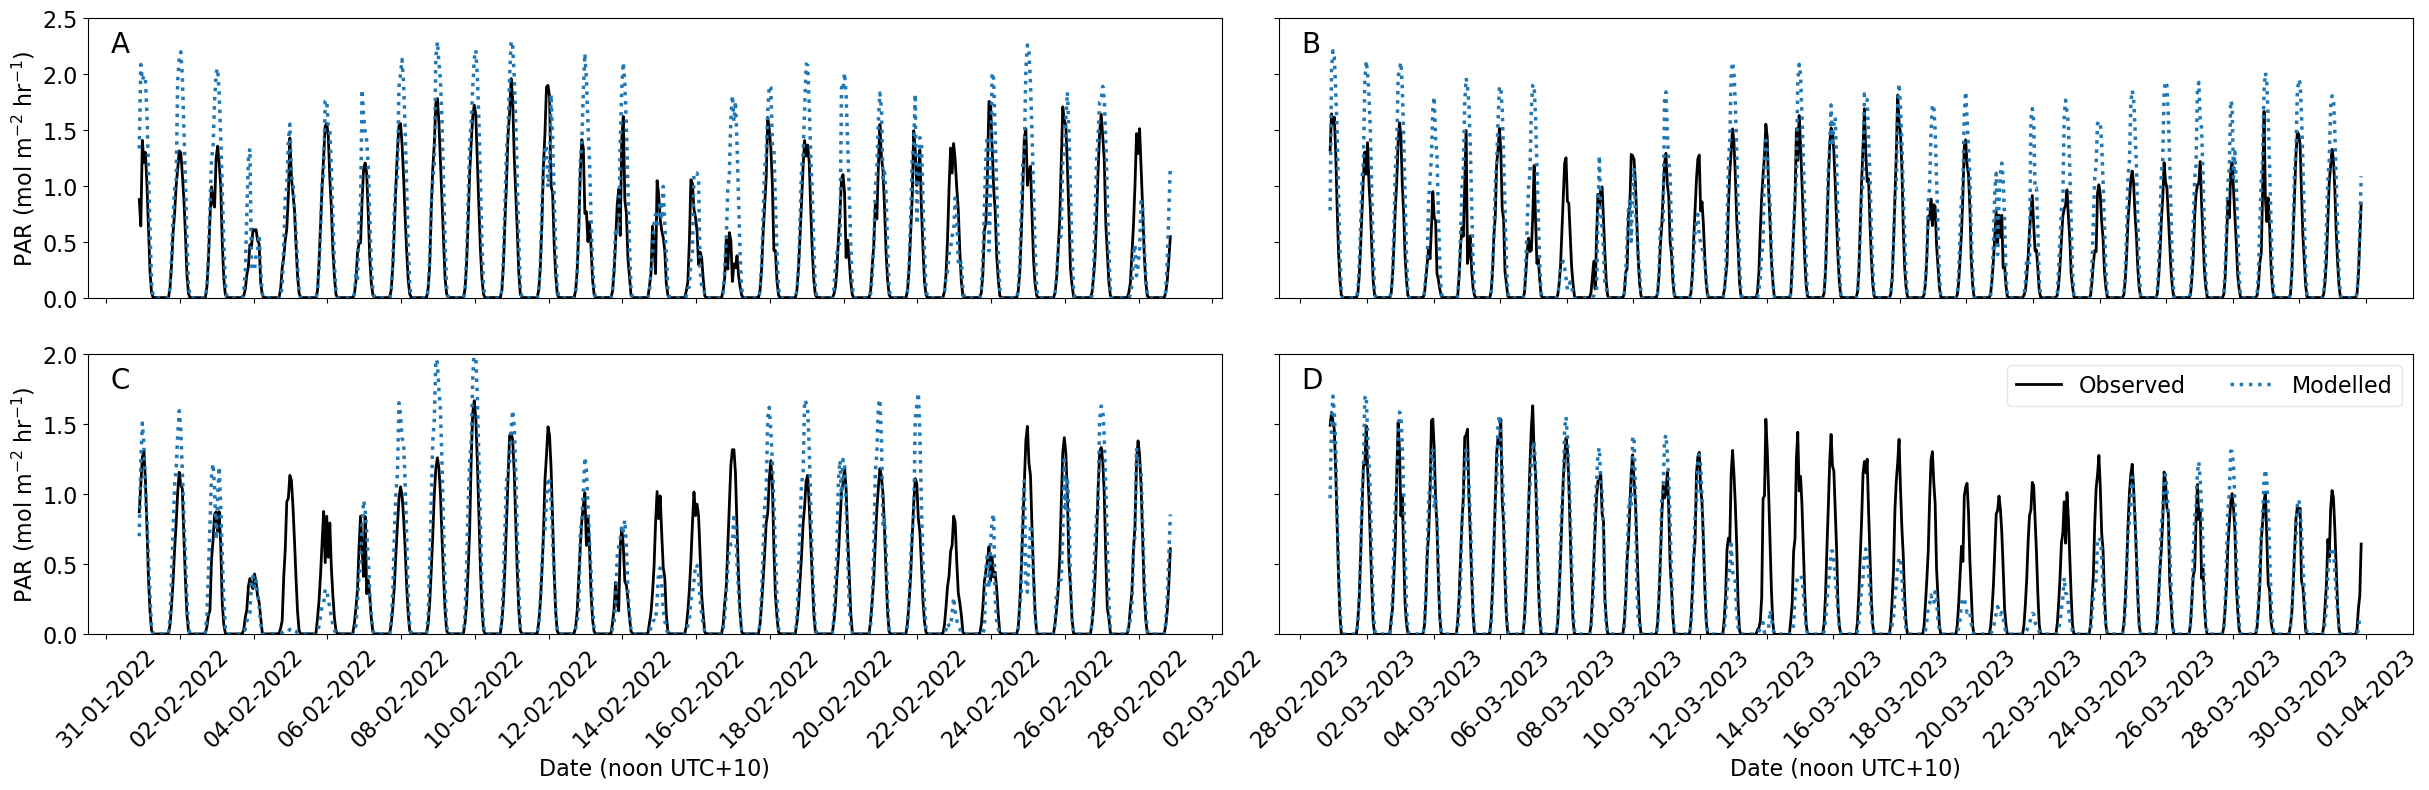


Davies Reef 2022:
╒════════════════════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤═════════╤═════════╤═════════╤═════════╤════════╤════════════╤════════╤════════╤═══════════════╤════════╕
│ Variable                   │ # points   │ Observed   │ Observed   │ Observed   │ Observed   │ Model   │ Model   │ Model   │ Model   │ Bias   │ Bias (%)   │ RMSE   │ NMBF   │ Spearmans r   │ p      │
│                            │            │ mean       │ min        │ max        │ SD         │ mean    │ min     │ max     │ SD      │        │            │        │        │               │        │
╞════════════════════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═════════╪═════════╪═════════╪═════════╪════════╪════════════╪════════╪════════╪═══════════════╪════════╡
│ FD_PAR_umole_m-2_s-1 (PAR) │ 672        │ 0.3682     │ 0.0033     │ 1.9595     │ 0.5052     │ 0.4909  │ 0       │ 2.2944  │ 0.6664  │ 0.1227 │ -2.4136    │ 0.3549 │ 0.3333 │ 0

In [11]:
model_var = 'PAR'
obs_var = 'FD_PAR_umole_m-2_s-1'
fout = fig_dir + 'SeawaterPAR_EcoRRAP.png'
ylabel = 'PAR (mol m$^{-2}$ hr$^{-1}$)'

# Format data for plotting - timestamps already aligned for other datasets above (seawater temperature)
model_HFD_22, dummy = align_times(ems_heron_22_FD, ER_Heron_22)
model_HFS_23, dummy = align_times(ems_heron_22_FS, ER_Heron_22)

obs_D22[obs_var] = obs_D22[obs_var] *1e-6 *60*60            # umol/m2/s –> mol/m2/hr
obs_D23[obs_var] = obs_D23[obs_var] *1e-6 *60*60
obs_H22[obs_var] = obs_H22[obs_var] *1e-6 *60*60
obs_H23[obs_var] = obs_H23[obs_var] *1e-6 *60*60
    
model_DFD_22[model_var] = model_DFD_22[model_var] *60*60    # mol/m2/s –> mol/m2/hr
model_DFD_23[model_var] = model_DFD_23[model_var] *60*60 
model_HFD_22[model_var] = model_HFD_22[model_var] *60*60 
model_HFD_23[model_var] = model_HFD_23[model_var] *60*60 

# Plot time-series
nrows = 2
ncols = 2
fig, axs = plt.subplots(nrows,ncols,figsize=(15*ncols,4*nrows),sharex='col',sharey='row')

obs_par_line = {'linestyle':'-', 'color':'k', 'linewidth':2} 
model_par_line = {'linestyle':':', 'color':'C0', 'linewidth':2.5}  

for iplt in range(nrows*ncols):
    irow = iplt // ncols
    icol = iplt % ncols 
    iax = axs[irow,icol]
    
    # Davies Reef
    if (irow==0):
        if (icol==0):
            iax.plot(obs_D22['time'], obs_D22[obs_var], **obs_par_line, label='Observed')
            iax.plot(model_DFD_22['time'], model_DFD_22[model_var], **model_par_line, label='Modelled')
            iax.set(ylabel=ylabel)
            iax.set_ylim([0,2.5])
        elif (icol==1):
            iax.plot(obs_D23['time'], obs_D23[obs_var], **obs_par_line, label='Observed')
            iax.plot(model_DFD_23['time'], model_DFD_23[model_var], **model_par_line, label='Modelled')

    # Heron Island
    elif (irow==1):
        if (icol==0):
            iax.plot(obs_H22['time'], obs_H22[obs_var], **obs_par_line, label='Observed')
            iax.plot(model_HFD_22['time'], model_HFD_22[model_var], **model_par_line, label='Modelled')
            iax.set(ylabel=ylabel)
            iax.set_ylim([0,2.0])
            start_dt = dt.datetime(model_HFD_22.time[0].dt.year.values, model_HFD_22.time[0].dt.month.values, model_HFD_22.time[0].dt.day.values, 2)
            xtick_rule = rrulewrapper(freq=DAILY, interval=2, byhour=2, dtstart=start_dt)
            xtick_loc = RRuleLocator(xtick_rule)
            iax.xaxis.set_major_formatter(date_form)
            iax.xaxis.set_major_locator(xtick_loc)
            
        elif (icol==1):
            iax.plot(obs_H23['time'], obs_H23[obs_var], **obs_par_line, label='Observed')
            iax.plot(model_HFD_23['time'], model_HFD_23[model_var], **model_par_line, label='Modelled')
            start_dt = dt.datetime(model_HFD_23.time[0].dt.year.values, model_HFD_23.time[0].dt.month.values, model_HFD_23.time[0].dt.day.values, 2)
            xtick_rule = rrulewrapper(freq=DAILY, interval=2, byhour=2, dtstart=start_dt)
            xtick_loc = RRuleLocator(xtick_rule)
            iax.xaxis.set_major_formatter(date_form)
            iax.xaxis.set_major_locator(xtick_loc)
            
    iax.annotate(plt_labels[iplt], xy=(0.1,0.1), xycoords='axes fraction', xytext=(0.02,0.88), color='black', fontsize=fontsize)
    if irow == nrows-1:
        iax.tick_params('x', labelrotation=45)
        iax.set_xlabel('Date (noon UTC+10)')
    
# Add legend and save
axs[-1,-1].legend(loc='best', framealpha=0.5, ncols=2)
plt.subplots_adjust(wspace=0.05, hspace=0.2)
plt.savefig(fout, bbox_inches='tight')
plt.show()

# Summary and bias metrics
print(f'\nDavies Reef 2022:')
generate_summary_table(obs_D22, model_DFD_22, [obs_var], [model_var])

print(f'\nDavies Reef 2023:')
generate_summary_table(obs_D23, model_DFD_23, [obs_var], [model_var])

print(f'\nHeron Island 2022:')
generate_summary_table(obs_H22, model_HFD_22, [obs_var], [model_var])

print(f'\nHeron Island 2023:')
generate_summary_table(obs_H23, model_HFD_23, [obs_var], [model_var])


## 